# Create DataFrame #


In [ ]:
import pandas as pd

df = pd.read_csv('DetectorData_167_1__2_.txt', skipinitialspace=True, index_col=False)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['DateTimeStamp'] = pd.to_datetime(df['DateTimeStamp'], format='%m/%d/%Y %I:%M:%S %p')

print(df.head())

        DateTimeStamp  RoadwayID  SegmentID  Lane  Speed  Volume  Volume1  \
0 2026-05-17 00:00:00        167          1     1     63     239        2   
1 2026-05-17 00:15:00        167          1     1     65     196        0   
2 2026-05-17 00:30:00        167          1     1     63     220        0   
3 2026-05-17 00:45:00        167          1     1     65     154        0   
4 2026-05-17 01:00:00        167          1     1     65     156        0   

   Volume2  Volume3  Volume4  Volume5  Volume6  Occupancy  Poll_Count  Failure  
0      237        0        0        0        0          5          15        0  
1      196        0        0        0        0          4          15        0  
2      220        0        0        0        0          5          15        0  
3      154        0        0        0        0          3          15        0  
4      156        0        0        0        0          3          15        0  


## Data Overview ##

In [ ]:
print(df.shape)
print(df.dtypes)


(1438, 15)
DateTimeStamp    datetime64[ns]
RoadwayID                 int64
SegmentID                 int64
Lane                      int64
Speed                     int64
Volume                    int64
Volume1                   int64
Volume2                   int64
Volume3                   int64
Volume4                   int64
Volume5                   int64
Volume6                   int64
Occupancy                 int64
Poll_Count                int64
Failure                   int64
dtype: object


## Change dtype for DateTimeStamp to date and time instead of object ##

In [ ]:
df['DateTimeStamp'] = pd.to_datetime(df['DateTimeStamp'])
print(df.dtypes)


DateTimeStamp    datetime64[ns]
RoadwayID                 int64
SegmentID                 int64
Lane                      int64
Speed                     int64
Volume                    int64
Volume1                   int64
Volume2                   int64
Volume3                   int64
Volume4                   int64
Volume5                   int64
Volume6                   int64
Occupancy                 int64
Poll_Count                int64
Failure                   int64
dtype: object


## Check for Missing Timestamps ##

In [ ]:
full_range = pd.date_range(start='2026-05-17', end='2026-05-31 23:45:00', freq='15min')

missing = full_range[~full_range.isin(df['DateTimeStamp'])]

print(missing)

DatetimeIndex(['2026-05-17 17:30:00', '2026-05-17 20:30:00',
               '2026-05-17 20:45:00', '2026-05-18 06:15:00',
               '2026-05-18 07:00:00', '2026-05-18 09:15:00',
               '2026-05-18 10:15:00', '2026-05-18 13:00:00',
               '2026-05-18 13:45:00', '2026-05-19 02:30:00',
               '2026-05-19 09:45:00', '2026-05-19 10:00:00',
               '2026-05-19 10:15:00', '2026-05-19 20:00:00',
               '2026-05-19 21:00:00', '2026-05-20 00:00:00',
               '2026-05-20 07:00:00', '2026-05-20 13:30:00',
               '2026-05-21 06:00:00', '2026-05-21 07:30:00',
               '2026-05-21 07:45:00', '2026-05-21 15:45:00',
               '2026-05-22 02:15:00', '2026-05-22 02:45:00',
               '2026-05-22 05:45:00', '2026-05-22 10:15:00',
               '2026-05-22 14:30:00', '2026-05-22 19:30:00',
               '2026-05-23 12:30:00', '2026-05-23 22:15:00',
               '2026-05-24 01:30:00', '2026-05-25 05:45:00',
               '2026-05-

## Count Missing Timestamps ##

In [ ]:
print(f'Total expected readings: 1440')
print(f'Total actual readings: {len(df)}')
print(f'Total missing readings: {len(missing)}')

Total expected readings: 1440
Total actual readings: 1438
Total missing readings: 57


In [ ]:
print(df.columns.tolist())

['DateTimeStamp', 'RoadwayID', 'SegmentID', 'Lane', 'Speed', 'Volume', 'Volume1', 'Volume2', 'Volume3', 'Volume4', 'Volume5', 'Volume6', 'Occupancy', 'Poll_Count', 'Failure']


In [ ]:
print(df['DateTimeStamp'].head())

0   2026-05-17 00:00:00
1   2026-05-17 00:15:00
2   2026-05-17 00:30:00
3   2026-05-17 00:45:00
4   2026-05-17 01:00:00
Name: DateTimeStamp, dtype: datetime64[ns]


# Speed vs Time Plot #

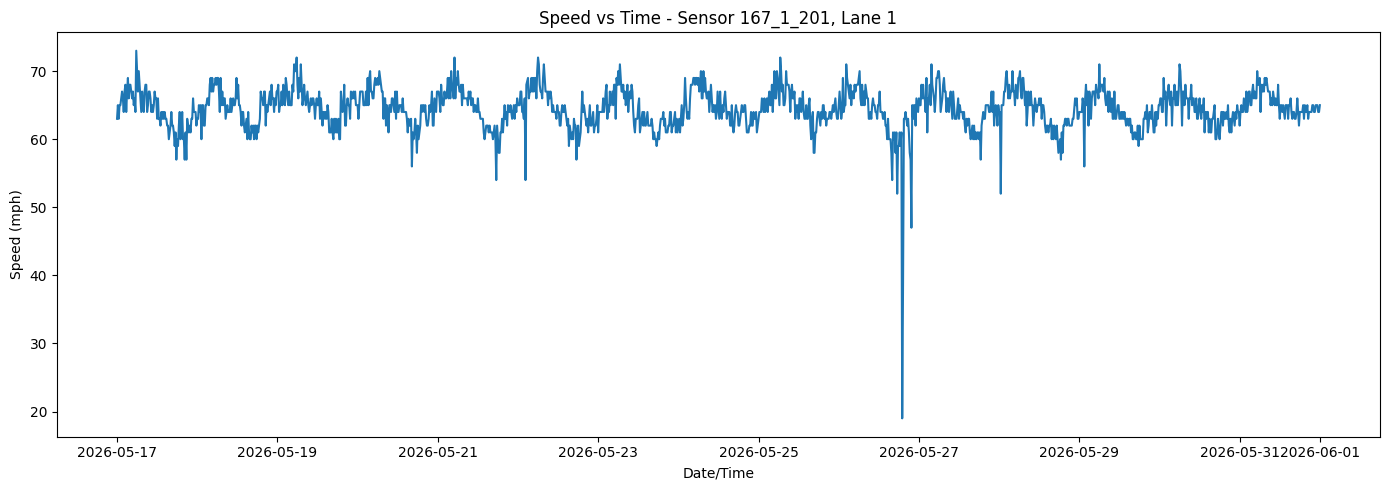

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df['DateTimeStamp'], df['Speed'])
plt.title('Speed vs Time - Sensor 167_1_201, Lane 1')
plt.xlabel('Date/Time')
plt.ylabel('Speed (mph)')
plt.tight_layout()
plt.show()

# Investigate Speed Drop – May 26-27 #

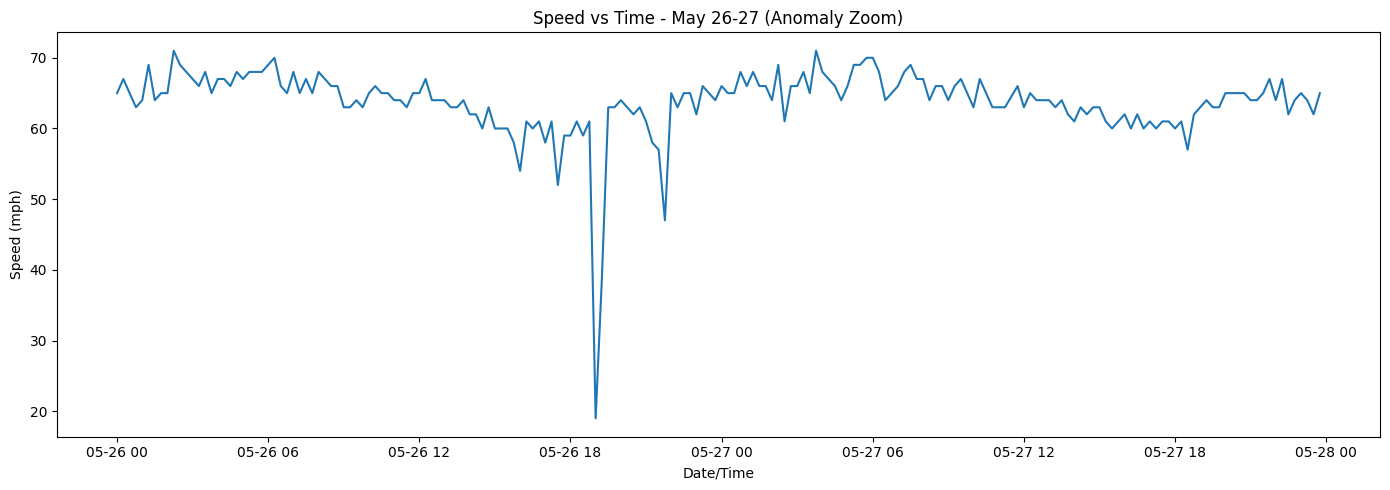

In [ ]:
mask = (df['DateTimeStamp']>= '2026-05-26') & (df['DateTimeStamp'] <= '2026-05-27 23:45:00')
df_drop = df[mask]

plt.figure(figsize=(14, 5))
plt.plot(df_drop['DateTimeStamp'], df_drop['Speed'])
plt.title('Speed vs Time - May 26-27 (Anomaly Zoom)')
plt.xlabel('Date/Time')
plt.ylabel('Speed (mph)')
plt.tight_layout()
plt.show()

## Find Exact Anomaly Timestamp ##

In [ ]:
min_speed_idx = df_drop['Speed'].idxmin()
print(df_drop.loc[min_speed_idx, ['DateTimeStamp', 'Speed', 'Volume', 'Occupancy']])

DateTimeStamp    2026-05-26 19:00:00
Speed                             19
Volume                           247
Occupancy                         31
Name: 939, dtype: object


# Aggregate Plot – By Time of Day #

  TimeOfDay  Avg_Speed  Avg_Occupancy  Total_Volume
0     00:00  64.187500       4.625000          3235
1     00:15  64.800000       3.800000          2673
2     00:30  63.600000       4.533333          2969
3     00:45  64.733333       2.933333          2215
4     01:00  65.400000       2.466667          1962
5     01:15  65.533333       1.866667          1541
6     01:30  64.666667       2.066667          1634
7     01:45  65.466667       1.333333          1214
8     02:00  65.600000       0.800000           985
9     02:15  65.400000       0.533333           938


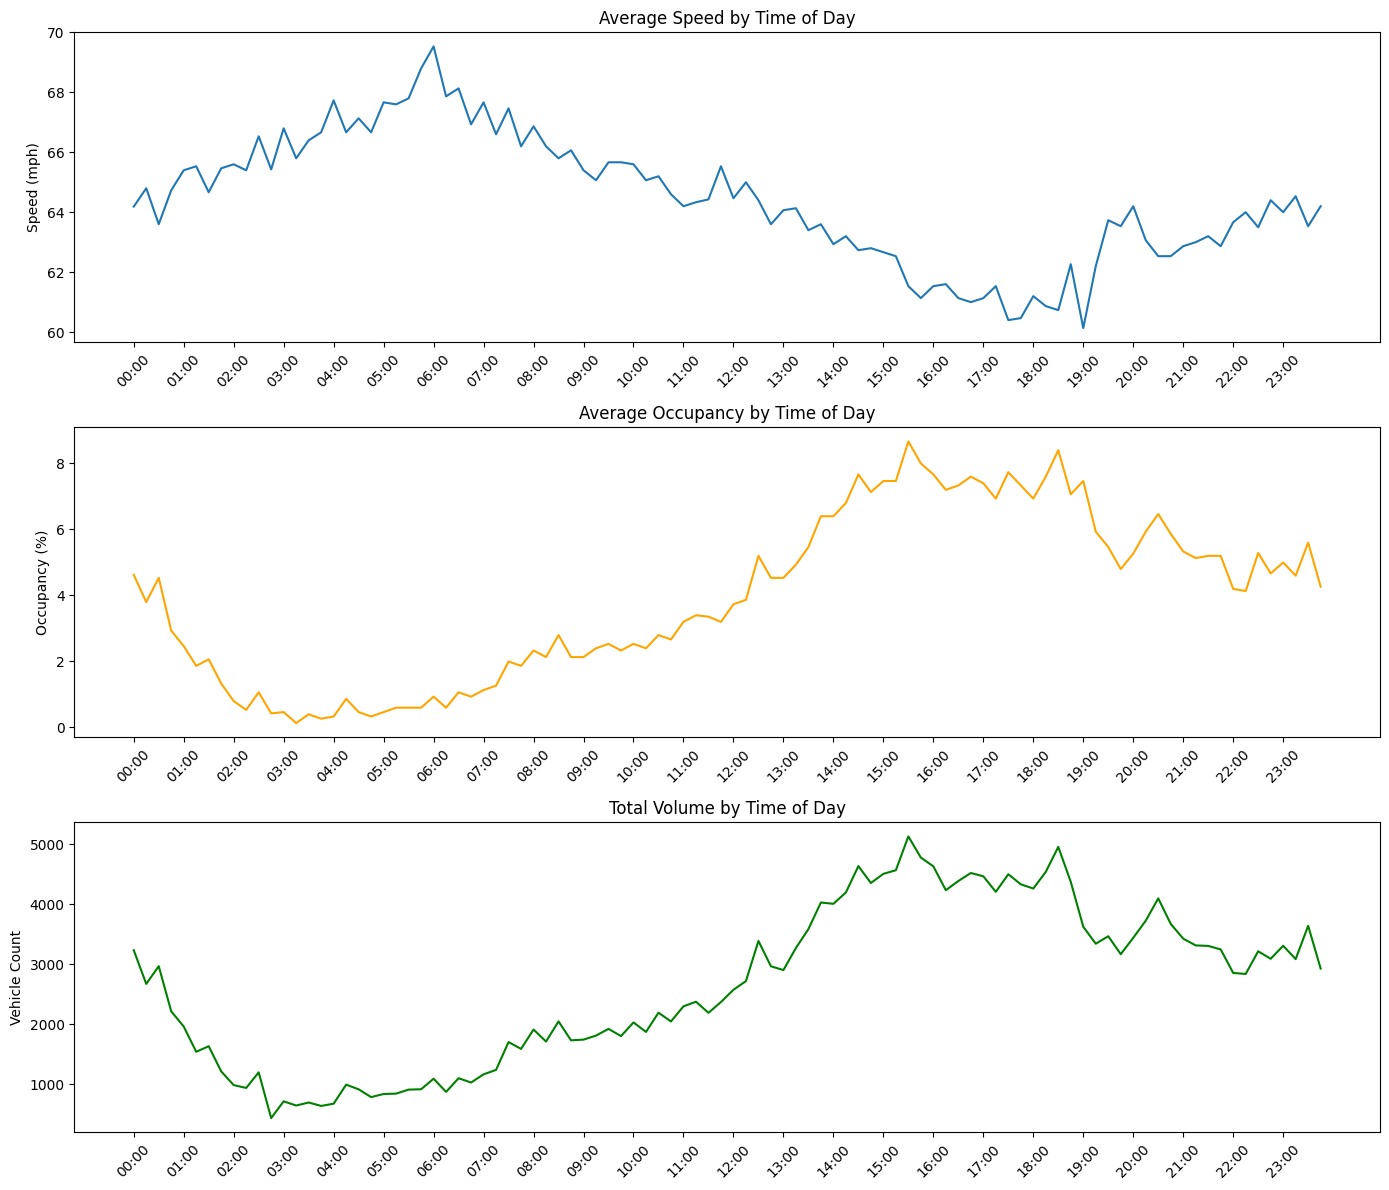

In [ ]:
df['TimeOfDay'] =df['DateTimeStamp'].dt.strftime('%H:%M')

agg = df.groupby('TimeOfDay').agg(
    Avg_Speed=('Speed', 'mean'),
    Avg_Occupancy=('Occupancy', 'mean'),
    Total_Volume=('Volume', 'sum')
).reset_index()

print(agg.head(10))

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(agg['TimeOfDay'], agg['Avg_Speed'])
axes[0].set_title('Average Speed by Time of Day')
axes[0].set_ylabel('Speed (mph)')
axes[0].set_xticks(agg['TimeOfDay'][::4])
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(agg['TimeOfDay'], agg['Avg_Occupancy'], color='orange')
axes[1].set_title('Average Occupancy by Time of Day')
axes[1].set_ylabel('Occupancy (%)')
axes[1].set_xticks(agg['TimeOfDay'][::4])
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(agg['TimeOfDay'], agg['Total_Volume'], color='green')
axes[2].set_title('Total Volume by Time of Day')
axes[2].set_ylabel('Vehicle Count')
axes[2].set_xticks(agg['TimeOfDay'][::4])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()